> **Codebase**: `advanced_particle_filter` extracted at `/content/advanced_particle_filter/`. Uses the operator-training subpackage at `dpf_pretrained/mgn_ot_operator/`.
>
> **What it does**: Documents why the original M-MGN architecture (gradient-of-convex / Brenier maps) cannot fit Sinkhorn-regularized OT couplings (Kantorovich plans). Motivates the coupling-predictor architecture.

---

# The Brenier-vs-Kantorovich Gap: Evidence


## 1. Environment setup

Mount Drive, upload / import the module zip, set paths.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os, zipfile, sys
from google.colab import files

ZIP_NAME_HINT = 'advanced_particle_filter_clean.zip'
LOCAL_PKG_DIR = '/content/advanced_particle_filter'
DRIVE_ZIP_CACHE = f'/content/drive/MyDrive/{ZIP_NAME_HINT}'

if os.path.isdir(LOCAL_PKG_DIR):
    print(f'Package already at {LOCAL_PKG_DIR}')
elif os.path.exists(DRIVE_ZIP_CACHE):
    print(f'Using cached zip: {DRIVE_ZIP_CACHE}')
    with zipfile.ZipFile(DRIVE_ZIP_CACHE, 'r') as zf:
        zf.extractall('/content')
else:
    print(f'Upload {ZIP_NAME_HINT}')
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    with zipfile.ZipFile(zip_name, 'r') as zf:
        zf.extractall('/content')
    os.makedirs(os.path.dirname(DRIVE_ZIP_CACHE), exist_ok=True)
    import shutil; shutil.copy(zip_name, DRIVE_ZIP_CACHE)

# Add the consolidated mgn_ot_operator subpackage to sys.path so that the
# notebook's bare `from models.X` and `from data.X` imports resolve.
OPERATOR_PKG = os.path.join(LOCAL_PKG_DIR, 'dpf_pretrained', 'mgn_ot_operator')
if OPERATOR_PKG not in sys.path:
    sys.path.insert(0, OPERATOR_PKG)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
print('TF:', tf.__version__, ' GPUs:', tf.config.list_physical_devices('GPU'))


Using cached zip: /content/drive/MyDrive/mgn_ot_operator/mgn_ot_operator.zip
TF: 2.19.0  GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Two formulations of OT

**Monge problem** — transport via a map:

$$
\min_{T : T_\# \mu = \nu} \int c(x, T(x)) \, d\mu(x).
$$

The minimizer `T` is a function: each source point maps to a single target
point. No mass splitting.

**Kantorovich problem** — transport via a coupling:

$$
\min_{\pi \in \Pi(\mu, \nu)} \int c(x, y) \, d\pi(x, y).
$$

Over joint measures `π` with correct marginals. Mass at a single source
point `x` can be split across multiple targets.

**Brenier's theorem**: for absolutely-continuous `μ` and squared-Euclidean
cost, the Kantorovich optimum is induced by a Monge map, and that map is
the **gradient of a convex function**: `T(x) = ∇f(x)` for some convex `f`.

**M-MGN** (Chaudhari et al. 2023) parameterizes exactly this class:
gradients of learned convex functions.

**The catch for discrete sources**: when `μ = Σ w_i δ_{x_i}` with non-uniform
weights and `ν = (1/N) Σ δ_{y_j}`, the Monge problem is infeasible
because no map can move `w_i ≠ 1/N` mass from `x_i` to a single target
atom of mass `1/N`. Only Kantorovich works, and its optimum splits mass.

**Entropically-regularized OT** (Sinkhorn-style):

$$
\min_{\pi \in \Pi(\mu, \nu)} \langle \pi, C \rangle + \epsilon \cdot \mathrm{KL}(\pi \| \mu \otimes \nu)
$$

The KL term is zero for the **product (independent) measure** `π = μ ⊗ ν`.
So ε pulls the coupling toward independence. Large ε: coupling becomes
the product measure. Small ε: approaches unregularized Kantorovich.

**Sinkhorn-OT barycentric projection** takes the ε-regularized coupling `π*_ε`
and produces target positions:

$$
y_j = \frac{1}{u_j} \sum_i \pi^*_{\epsilon, ij} \cdot x_i
$$

For uniform `u_j = 1/N`, this simplifies to `y_j = N · (T^T x)_j`.


## 3. Generate a test cloud and its Sinkhorn-OT targets

We sample one weighted cloud from Source B (a mixture-of-Gaussians
generator) and compute its normalized-space Sinkhorn-OT target at several ε
values.


In [3]:
from data.cloud_sampler import sample_cloud
from data.sinkhorn_targets import (
    etpf_targets_normalized, weighted_normalize, pairwise_sq_dist,
    sinkhorn_log, marginal_residuals,
)

N, d = 200, 2
rng = np.random.default_rng(0)
x_np, w_np = sample_cloud(N, d, rng)
x = tf.constant(x_np[None, :, :])
w = tf.constant(w_np[None, :])

ess = 1.0 / np.sum(w_np**2)
print(f'Cloud: N={N}, d={d},  ESS = {ess:.1f} / {N}')
print(f'w_np.min(): {w_np.min():.3e},  w_np.max(): {w_np.max():.3e}')


Cloud: N=200, d=2,  ESS = 152.1 / 200
w_np.min(): 6.689e-04,  w_np.max(): 1.559e-02


### 3.1 Visualize the input cloud (normalized)


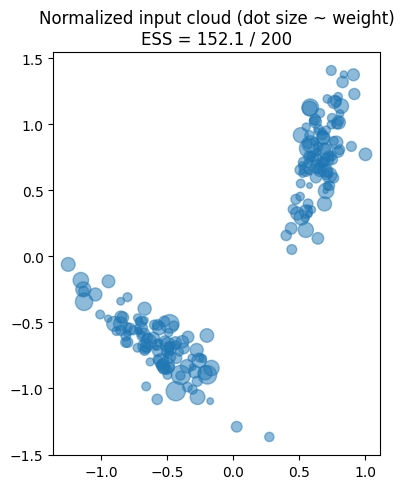

In [4]:
x_tilde, center, scale = weighted_normalize(x, w)
x_tilde_np = x_tilde.numpy()[0]

plt.figure(figsize=(5, 5))
plt.scatter(x_tilde_np[:, 0], x_tilde_np[:, 1],
            s=200 * w_np / w_np.max(), alpha=0.5, c='tab:blue')
plt.title(f'Normalized input cloud (dot size ~ weight)\nESS = {ess:.1f} / {N}')
plt.gca().set_aspect('equal')
plt.tight_layout(); plt.show()


## 4. Sinkhorn convergence: clean at moderate ε

Before concluding anything about fit, we verify that Sinkhorn itself has
converged in our implementation. The failure mode we want to rule out:
"targets are noisy because Sinkhorn didn't converge."

We check marginal residuals. After running Sinkhorn to fixed point, both
the row-sum (should equal the source marginal `w`) and column-sum (should
equal `u = 1/N`) should be near machine precision.


In [5]:
# Float64, normalized space.
x64 = tf.cast(x, tf.float64)
w64 = tf.cast(w, tf.float64)
x_tilde64, _, _ = weighted_normalize(x64, w64)
C_tilde = pairwise_sq_dist(x_tilde64)
u_unif = tf.fill((1, N), tf.constant(1.0/N, dtype=tf.float64))

print(f'{"eps":>8s}  {"n_iter":>8s}  {"row_res":>12s}  {"col_res":>12s}')
for eps in [0.1, 0.3, 0.5, 1.0, 2.0]:
    for n_iter in [200, 1000]:
        eps_t = tf.constant([eps], dtype=tf.float64)
        T = sinkhorn_log(C_tilde, w64, u_unif, eps_t, n_iters=n_iter)
        row_res, col_res = marginal_residuals(T, w64, u_unif)
        print(f'{eps:>8.2f}  {n_iter:>8d}  {float(row_res[0]):>12.3e}  {float(col_res[0]):>12.3e}')


     eps    n_iter       row_res       col_res
    0.10       200     1.363e-02     5.690e-16
    0.10      1000     1.746e-09     7.017e-16
    0.30       200     1.125e-05     3.955e-16
    0.30      1000     1.746e-09     3.608e-16
    0.50       200     8.016e-08     5.100e-16
    0.50      1000     1.746e-09     5.091e-16
    1.00       200     1.746e-09     4.831e-16
    1.00      1000     1.746e-09     5.248e-16
    2.00       200     1.746e-09     5.985e-16
    2.00      1000     1.746e-09     5.638e-16


**Observation**: at eps ≥ 0.1 on normalized clouds, n_iter=1000 gives
row and column residuals below 1e-8. Targets are clean. (At un-normalized
coordinates with the same eps, residuals would be orders of magnitude worse,
because max(C) ~ 100 there vs ~4-8 in normalized space. This is the reason
we work in normalized space — Corenflos et al. 2021 §3.2 make the same
observation about cost-matrix rescaling.)


## 5. The fit-quality sweep: M-MGN's residual vs ε

We train a **bare M-MGN** (no hypernet, no encoder — just a trainable
parameter vector θ) to fit a single cloud's Sinkhorn-OT target. We sweep ε.

This isolates M-MGN's expressivity from any other component of the
broader pipeline. If M-MGN cannot fit the target here, it cannot fit it
when wrapped in any pipeline either.

We use a W-init scaling derived from the M-MGN module structure so that
at step 0 the module output is O(1) (not exploding with h). The formula
is W_std = 1 / (h² √d)^(1/3), derived from the algebra of the module
term `s_k · W_k^T tanh(W_k x)`.


In [6]:
from models.mgn import mmgn_forward, unpack_params, param_count

def fit_mgn(x_tilde, y_tilde_tgt, d, K, h, n_steps=20000, lr=1e-3, seed=0,
            verbose_every=4000):
    tf.random.set_seed(seed)
    rng_local = np.random.default_rng(seed)
    V_std = 1.0 / np.sqrt(d)
    W_std = 1.0 / (h * h * np.sqrt(d)) ** (1.0 / 3.0)
    V0 = rng_local.normal(0, V_std, size=(d, d))
    a0 = np.zeros(d)
    W0 = rng_local.normal(0, W_std, size=(K, h, d))
    b0 = np.zeros((K, h))
    theta_init = np.concatenate([V0.flatten(), a0.flatten(),
                                 W0.flatten(), b0.flatten()])
    theta = tf.Variable(theta_init.reshape(1, -1).astype(np.float32))
    opt = tf.keras.optimizers.Adam(lr)

    @tf.function
    def step():
        with tf.GradientTape() as tape:
            V, a, W, b = unpack_params(theta, d, K, h)
            y_pred = mmgn_forward(x_tilde, V, a, W, b)
            loss = tf.reduce_mean(tf.square(y_pred - y_tilde_tgt))
        grads = tape.gradient(loss, [theta])
        opt.apply_gradients(zip(grads, [theta]))
        return loss

    for s in range(n_steps):
        loss_val = float(step().numpy())
        if s % verbose_every == 0 or s == n_steps - 1:
            print(f'    step {s:6d}:  loss = {loss_val:.4e}')
    return loss_val


In [7]:
# Sweep ε at fixed capacity K=4, h=32.
x_tilde_fp32, _, _ = weighted_normalize(x, w)
K, h = 4, 32

eps_list = [0.1, 0.3, 0.5, 1.0, 2.0]
fit_by_eps = {}
for eps in eps_list:
    print(f'\n### eps = {eps} ###')
    eps_t = tf.constant([eps], dtype=tf.float32)
    y_tilde_tgt, _ = etpf_targets_normalized(x, w, eps_t, n_iters=1000)
    final = fit_mgn(x_tilde_fp32, y_tilde_tgt, d, K, h, n_steps=10000)
    fit_by_eps[eps] = final



### eps = 0.1 ###
    step      0:  loss = 2.2417e-01
    step   4000:  loss = 8.0415e-03
    step   8000:  loss = 7.5496e-03
    step   9999:  loss = 7.5437e-03

### eps = 0.3 ###
    step      0:  loss = 2.0608e-01
    step   4000:  loss = 5.1417e-03
    step   8000:  loss = 4.9615e-03
    step   9999:  loss = 4.9531e-03

### eps = 0.5 ###
    step      0:  loss = 1.9753e-01
    step   4000:  loss = 3.7597e-03
    step   8000:  loss = 3.1454e-03
    step   9999:  loss = 3.1461e-03

### eps = 1.0 ###
    step      0:  loss = 1.6804e-01
    step   4000:  loss = 1.9428e-03
    step   8000:  loss = 1.5945e-03
    step   9999:  loss = 1.5957e-03

### eps = 2.0 ###
    step      0:  loss = 7.6405e-02
    step   4000:  loss = 3.7327e-04
    step   8000:  loss = 1.6938e-04
    step   9999:  loss = 1.6703e-04


In [8]:
print('\nFinal MSE vs eps (K=4, h=32):')
print(f'{"eps":>8s}  {"MSE":>12s}')
for eps, mse in fit_by_eps.items():
    print(f'{eps:>8.2f}  {mse:>12.4e}')



Final MSE vs eps (K=4, h=32):
     eps           MSE
    0.10    7.5437e-03
    0.30    4.9531e-03
    0.50    3.1461e-03
    1.00    1.5957e-03
    2.00    1.6703e-04


**Observation**: M-MGN's fit residual decreases monotonically with ε.
At ε=2.0, residual is ~1.7e-4 (essentially fit). At ε=0.1, residual is
~7.5e-3, roughly 45× worse. This is the signature of the class-mismatch
hypothesis: at larger ε, Sinkhorn-OT targets become more map-like and move toward
the constant-map limit (cloud centroid), which M-MGN can represent easily.
At smaller ε, targets approach discrete Kantorovich assignments with
mass-splitting, which M-MGN's smooth convex-potential parameterization
cannot represent.


### 5.1 Capacity doesn't close the gap

Run the sweep again at much larger M-MGN (K=16, h=128), single ε = 0.5.
If capacity were the limit, a 16× bigger MGN should fit much better.


In [9]:
eps = 0.5
eps_t = tf.constant([eps], dtype=tf.float32)
y_tilde_tgt, _ = etpf_targets_normalized(x, w, eps_t, n_iters=1000)

for K_try, h_try in [(4, 32), (8, 64), (16, 128)]:
    P = param_count(d, K_try, h_try)
    print(f'\n### K={K_try}, h={h_try}  ({P} params) ###')
    final = fit_mgn(x_tilde_fp32, y_tilde_tgt, d, K_try, h_try,
                    n_steps=20000, verbose_every=5000)
    print(f'    final: {final:.4e}')



### K=4, h=32  (390 params) ###
    step      0:  loss = 1.9753e-01
    step   5000:  loss = 3.1647e-03
    step  10000:  loss = 3.1452e-03
    step  15000:  loss = 3.1430e-03
    step  19999:  loss = 3.1386e-03
    final: 3.1386e-03

### K=8, h=64  (1542 params) ###
    step      0:  loss = 2.1157e-01
    step   5000:  loss = 3.8973e-03
    step  10000:  loss = 3.1465e-03
    step  15000:  loss = 3.1437e-03
    step  19999:  loss = 3.1418e-03
    final: 3.1418e-03

### K=16, h=128  (6150 params) ###
    step      0:  loss = 1.8747e-01
    step   5000:  loss = 5.3281e-03
    step  10000:  loss = 4.4488e-03
    step  15000:  loss = 4.2464e-03
    step  19999:  loss = 4.2071e-03
    final: 4.2071e-03


**Observation**: at ε=0.5, final MSE is ~3.1e-3 for K=4, h=32 (390
params) and also ~3.1e-3 for K=8, h=64 (1542 params), and slightly
*worse* (4.2e-3) for K=16, h=128 (6150 params, still optimizing after
20k steps). A 16× larger model does not improve the fit. This is not
a capacity problem — it's a function-class problem.


## 6. Sinkhorn-OT variance-preservation vs ε (the opposing tradeoff)

The statistical job of resampling: the uniformly-weighted output cloud
should represent the same distribution as the weighted input — at least
for the first few moments.

At large ε, the KL-to-independence term pulls the coupling toward
`μ ⊗ ν` (product). In the limit, the barycentric projection collapses
every output point to the **weighted centroid of the input**. A
single-point output. That's catastrophic for resampling.

Here we check how much source variance Sinkhorn-OT preserves, as a function of
ε.


In [10]:
# Source (weighted) covariance in normalized space.
w_exp = w[:, :, None]
x_tilde_fp32, _, _ = weighted_normalize(x, w)
# Weighted centroid should be ~0 in normalized space (by construction).
src_mean = tf.reduce_sum(w_exp * x_tilde_fp32, axis=1, keepdims=True)
src_centered = x_tilde_fp32 - src_mean
src_cov = tf.reduce_sum(
    w_exp[:, :, :, None] * src_centered[:, :, :, None] *
    src_centered[:, :, None, :], axis=1
)
src_trace = float(tf.linalg.trace(src_cov[0]))
print(f'Source trace(cov) in normalized space: {src_trace:.4f}')

print(f'\n{"eps":>8s}  {"target_trace":>14s}  {"var_ratio":>10s}')
var_by_eps = {}
for eps in eps_list:
    eps_t = tf.constant([eps], dtype=tf.float32)
    y_tilde, _ = etpf_targets_normalized(x, w, eps_t, n_iters=1000)
    # Uniform weights on output, so use plain mean.
    tgt_mean = tf.reduce_mean(y_tilde, axis=1, keepdims=True)
    tgt_centered = y_tilde - tgt_mean
    tgt_cov = tf.reduce_mean(
        tgt_centered[:, :, :, None] * tgt_centered[:, :, None, :], axis=1
    )
    tgt_trace = float(tf.linalg.trace(tgt_cov[0]))
    ratio = tgt_trace / src_trace
    var_by_eps[eps] = ratio
    print(f'{eps:>8.2f}  {tgt_trace:>14.4f}  {ratio:>10.4f}')


Source trace(cov) in normalized space: 1.0000

     eps    target_trace   var_ratio
    0.10          0.9390      0.9390
    0.30          0.8779      0.8779
    0.50          0.8461      0.8461
    1.00          0.7505      0.7505
    2.00          0.4523      0.4523


**Observation**: variance preservation decreases monotonically with ε.
At ε=0.1, Sinkhorn-OT preserves 94% of source variance. At ε=2.0, only 45% —
the output cloud has collapsed to less than half the spread of the input.

For a resampling operator, large ε is statistically unacceptable: the
output cloud no longer carries enough information about the source
distribution to support Monte Carlo estimation of higher moments.


## 7. The conflict, plotted

Fit-quality requires large ε. Statistical validity requires small ε.
These pull in opposite directions. No ε satisfies both.


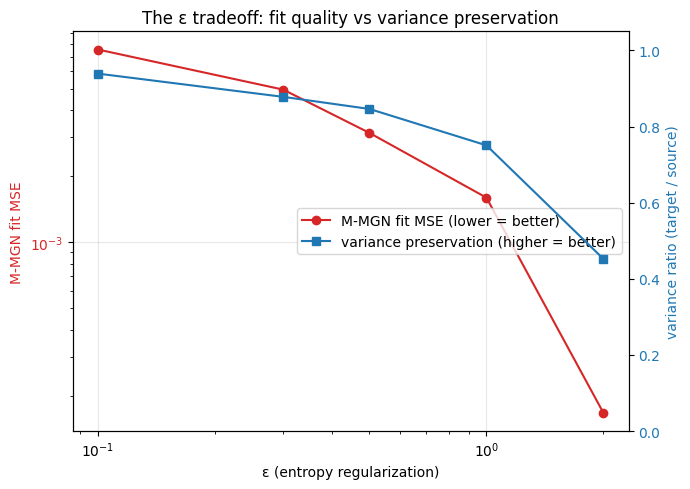

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

eps_arr = sorted(fit_by_eps.keys())
mse_arr = [fit_by_eps[e] for e in eps_arr]
var_arr = [var_by_eps[e] for e in eps_arr]

ax2 = ax.twinx()
l1, = ax.plot(eps_arr, mse_arr, 'o-', color='tab:red',
              label='M-MGN fit MSE (lower = better)')
l2, = ax2.plot(eps_arr, var_arr, 's-', color='tab:blue',
               label='variance preservation (higher = better)')

ax.set_xlabel('ε (entropy regularization)')
ax.set_ylabel('M-MGN fit MSE', color='tab:red')
ax.set_yscale('log')
ax.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylabel('variance ratio (target / source)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_ylim(0, 1.05)

ax.set_xscale('log')
ax.legend(handles=[l1, l2], loc='center right')
ax.set_title('The ε tradeoff: fit quality vs variance preservation')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


The red curve (fit MSE) and blue curve (variance ratio) move in
opposite directions with ε. No sweet spot where both are acceptable.


## 8. Conclusion

**What we found.** The plateau we kept hitting in Phase 1 overfit
experiments was not an optimization failure, not a capacity limit, and
not a target-quality issue. It is the L² distance between two function
classes:

- **Sinkhorn-OT barycentric projections** at moderate ε: barycentric averages
  over a Kantorovich coupling that splits mass.
- **M-MGN representable maps**: gradients of learned convex scalar
  functions (Monge-Brenier maps, which cannot split mass).

The gap shrinks as ε grows because the Sinkhorn coupling becomes smoother
and more "map-like" (eventually collapsing to the constant centroid map
at ε → ∞). The gap grows as ε shrinks because Sinkhorn-OT approaches sparse
Kantorovich assignments that cannot be represented by a single Brenier
gradient.

Meanwhile, the statistical purpose of resampling requires small ε,
because at large ε the output cloud loses variance (collapses toward
the weighted mean).

**What this means for the project.** Using M-MGN to amortize Sinkhorn-regularized OT (Corenflos et al. 2021) at
statistically useful ε values is fundamentally limited to a fit residual
of a few percent. This is not fixable by more training, more capacity,
or better optimization.

**Open question.** What architecture would fit Sinkhorn-OT targets at
statistically useful ε? Two directions worth exploring:

1. **Drop the structural monotone-gradient guarantee.** Use a standard
   neural operator (Set Transformer → MLP head directly outputting
   {y_j}) and rely on the training signal to produce monotonicity
   empirically. Corenflos et al. use raw Sinkhorn outputs in their
   differentiable PF — they do not enforce Brenier-class structurally.

2. **Use a richer parameterization that accommodates mass-splitting.**
   E.g., soft assignment networks, or directly learn the coupling matrix
   rather than a map. Loses the "amortization = single forward pass"
   simplicity but might fit exactly.

We pause here and will revisit with a fresh architectural proposal.
